In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

### load excel sheet with data

### Assumptions 


### Emissions, based on : 
##### Plane - Domestic (between 700 and 1500km) <= 0.22928 kg CO2e/km; 
##### Plane - Short-haul (between 1500 and 8000km) = 0.12786 kg CO2e/km; 
##### Plane - Long-haul (>8000km) = 0.15282 kg CO2e/km; 
##### Car/Taxi = 0.16725 kg CO2e/km; --> factor 1.3 added to distance
##### Bus = 0.02776 kg CO2e/km; --> factor 1.3 added to distance
##### Ferry = 0.11270 kg CO2e/km; 
##### International rail = 0.00446 kg CO2e/km; --> factor 1.25 added to distance
##### National rail = 0.03546 kg CO2e/km; --> factor 1.25 added to distance
##### Walk/Cycle = 0 kg CO2e/km
#### --> we estimated an average of 0.06 CO2e/km for distances < 700km, i.e. via bus, rail, or car




#### Hotel stays:  10.4 kg CO2e/room-night
#### Conference center emissions: estimate of 5.25tCO2e for 1000 people per day = 5.25kg / person / conference day

### excel sheet should include: number of people attending and their location, including distance to conference location

### please update the following section!

In [17]:
## please UPDATE PATH!!
path = '/YOUR/PATH/TO/EXCELfile/'

## please update: length of the meeting (in days)
n_days = 5

## please update: depending on the length of the conference (n_days), what's the average stay per attendee?
n_night = 5 

## please update: what are the carbon emission of the conference center per day and participant? If not provided, we assume 5.25 kg/day/participant
center_CO2 = 5.25

## read excel file, please update filename!
df = pd.read_excel(path+'Rome_2019_data_example.xlsx', engine='openpyxl')

### quick summary of people attending and the different transportation modes

In [18]:

### xlsx should have the following columns: Distance (in km, to conference center), Attendees (number of attendees per location)
dist = np.array(df["Distance"]) #distance in km, one-way

N = np.array(df["Attendees"]) # how many people
N_sum = np.nansum(N)

## ordering into different categories depending on distance 

#####################################
## number of people per type of transport
#################################
### assumptinos are based on kilometers/distance to conference center

#numbers per scenario: how many people took what kind of flights?
#Vancouver
print('Total number of people attending '  + ': ' + str(N_sum))
ic =sum([N for N,d in zip(N,dist) if d >= 8000])
people_longhaul_percentage = round(ic/N_sum*100, 1)
print('long-haul '  + ': '+ str(ic))
lh =  sum([N for N,d in zip(N,dist) if d >= 1500 and d < 8000 ])
people_shorthaul_percentage = round(lh/N_sum*100, 1)
print('short-haul '  + ': '+ str(lh))
sh = sum([N for N,d in zip(N,dist) if d >= 700 and d < 1500])
people_domestic_percentage = round(sh/N_sum*100, 1)
print('domestic '  + ': ' + str(sh))
ra =  sum([N for N,d in zip(N,dist) if d < 700])
people_residence_percentage = round(ra/N_sum*100, 1)
print('rail/bus/car/ferry '  + ': ' + str(ra))

Total number of people attending : 3886
long-haul : 1336
short-haul : 785
domestic : 1370
rail/bus/car/ferry : 395


### generating graph with emissions

In [ ]:

## this is the 'old' calculation based on Atmosfair numbers
#num = number of people, d = distance; n*dist*2 for return *factor depending on distance
#summed up over all people and divided by 1000
#C1ic = sum([num*d*2*0.3 for num,d in zip(N,dist) if d >= 8000])/1000 #long haul factor: 0.3
#C1lh = sum([num*d*2*0.25 for num,d in zip(N,dist) if d >= 1500 and d < 8000])/1000 #short haul factor: 0.25
#C1sh = sum([num*d*2*0.2 for num,d in zip(N,dist) if d >= 700 and d < 1500])/1000 #domestic fligth factor: 0.2
#C1ra = sum([num*d*2*0.06 for num,d in zip(N,dist) if d < 700])/1000 #bus/train/car: 0.06

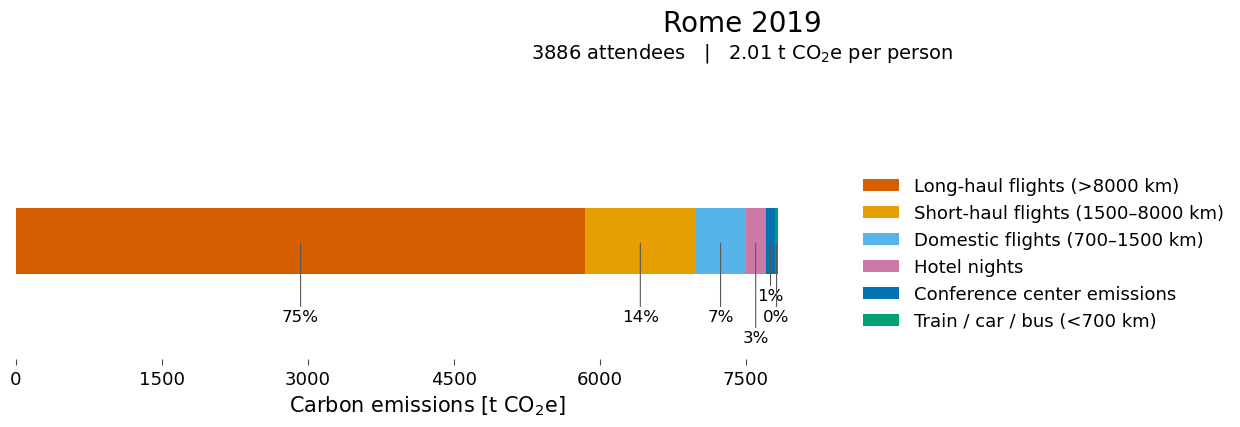

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --------------------------------------------------
# Calculate emissions: update factors if necessary!
# -------------------------------------------------
C1ic = sum([num*d*2*0.22028 for num, d in zip(N, dist) if d >= 8000]) / 1000  ## factor for plane-domestic
C1lh = sum([num*d*2*0.12786 for num, d in zip(N, dist) if d >= 1500 and d < 8000]) / 1000 ## factor for plane-short-haul
C1sh = sum([num*d*2*0.15282 for num, d in zip(N, dist) if d >= 700 and d < 1500]) / 1000 ## factor for plane-long-haul
C1ra = sum([num*d*2*1.3*0.06 for num, d in zip(N, dist) if d < 700]) / 1000 ## average factor for bus/car/train
nights = (N_sum * n_night * 10.4 / 1000)
conference_CO2 = (N_sum * n_days * center_CO2 / 1000)

values = [C1ic, C1lh, C1sh, C1ra, nights, conference_CO2]
labels = [
    "Long-haul flights (>8000 km)",
    "Short-haul flights (1500–8000 km)",
    "Domestic flights (700–1500 km)",
    "Train / car / bus (<700 km)",
    "Hotel nights",
    "Conference center emissions"
]

# Colorblind-safe palette
colors = ["#D55E00", "#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#0072B2"]

total_emissions = sum(values)

# ----------------------------
# Sort by emissions descending
# ----------------------------
data = sorted(zip(values, labels, colors), key=lambda x: x[0], reverse=True)

# ----------------------------
# Figure styling
# ----------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(16, 4.8))

# ----------------------------
# Dynamic x-axis
# ----------------------------
x_pad_right = total_emissions * 0.08
xmax = total_emissions + x_pad_right

# ----------------------------
# Compute bar centers first
# ----------------------------
left = 0
centers = []
for val, lab, col in data:
    centers.append(left + val / 2)
    left += val

# Spread label positions across the whole bar width
# so text does not overlap, while arrows still point to true centers
n = len(data)
label_x_positions = np.linspace(total_emissions * 0.06, total_emissions * 0.94, n)

# Keep label order matched to bar order from left to right
# by sorting centers and assigning spread positions in that same order
order = np.argsort(centers)
label_x = np.empty(n)
label_x[order] = label_x_positions

# ----------------------------
# Plot stacked horizontal bar
# ----------------------------
left = 0
bar_y = 0

# store label positions already used
placed_labels = []

for i, (val, lab, col) in enumerate(data):
    ax.barh(
        bar_y, val, left=left, height=0.5,
        color=col, edgecolor="none", label=lab
    )

    pct = 100 * val / total_emissions if total_emissions > 0 else 0
    x_center = left + val / 2

    # default label position below bar
    label_y = -0.52

    # if too close to an existing label, move it up/down
    for prev_x, prev_y in placed_labels:
        if abs(x_center - prev_x) < total_emissions * 0.06:
            if prev_y == -0.52:
                label_y = -0.68
            elif prev_y == -0.68:
                label_y = -0.36
            else:
                label_y = -0.52

    ax.annotate(
        f"{pct:.0f}%",
        xy=(x_center, bar_y - 0.02),     # point on bar
        xytext=(x_center, label_y),      # same x, shifted y if needed
        ha="center", va="top", fontsize=12,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.8,
            color="0.35",
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3,rad=0"
        )
    )

    placed_labels.append((x_center, label_y))
    left += val

# ----------------------------
# Title and subtitle
# ----------------------------
fig.suptitle("Rome 2019", y=0.97, fontsize=20)

fig.text(
    0.5, 0.88,
    f"{int(N_sum)} attendees   |   {total_emissions / N_sum:.2f} t CO$_2$e per person",
    ha="center", va="center", fontsize=14
)

# ----------------------------
# Axes formatting
# ----------------------------
ax.set_xlabel("Carbon emissions [t CO$_2$e]")
ax.set_yticks([])
ax.set_xlim(0, xmax)
ax.set_ylim(-0.9, 0.7)

ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="y", left=False)
ax.tick_params(axis="x", length=4, width=0.8, color="0.3")
ax.grid(False)

# Legend
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0.03, 0.08, 0.82, 0.82])
plt.savefig("Total_emissions.pdf")
plt.show()

## Two plots in one
## upper part: total emissions; 
## lower part: % of attendees per mode of transport

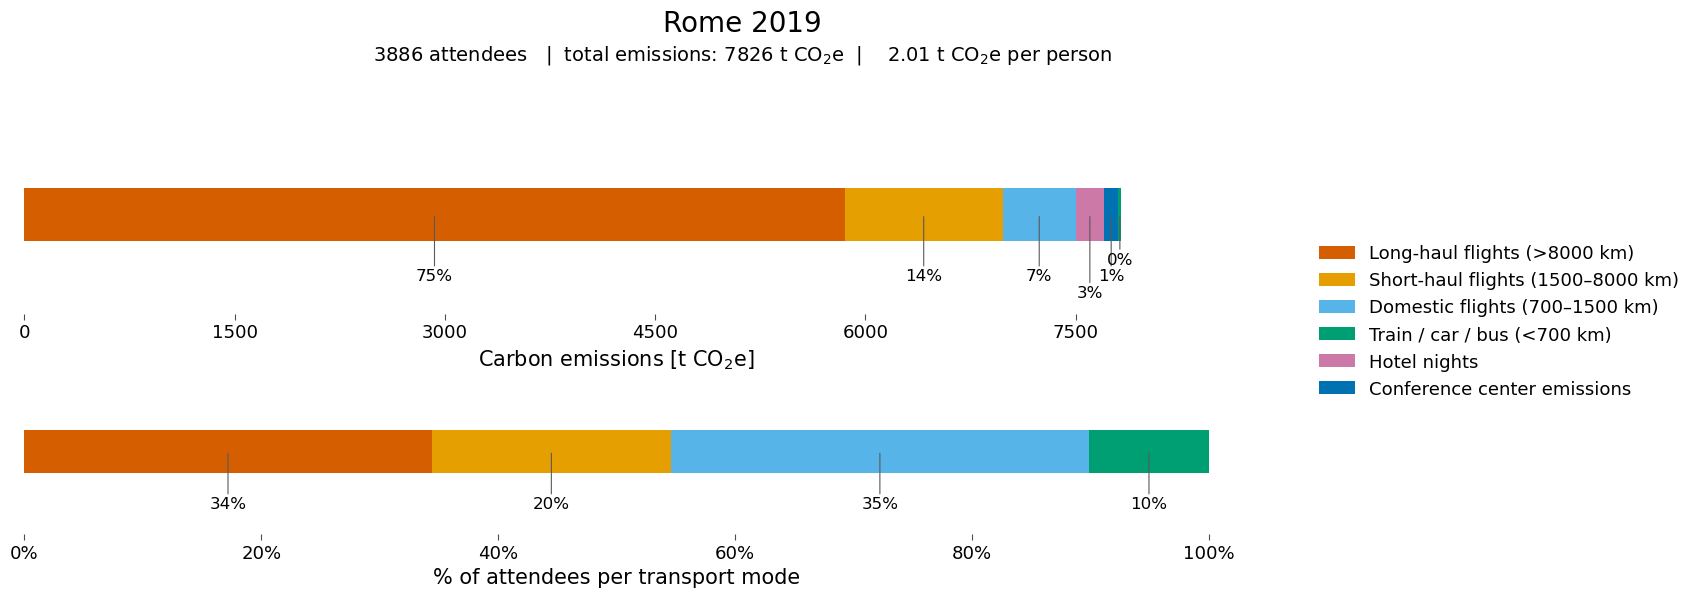

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from matplotlib.patches import Patch

# ----------------------------
# Calculate emissions
# ----------------------------
C1ic = sum([num*d*2*0.22028 for num, d in zip(N, dist) if d >= 8000]) / 1000
C1lh = sum([num*d*2*0.12786 for num, d in zip(N, dist) if d >= 1500 and d < 8000]) / 1000
C1sh = sum([num*d*2*0.15282 for num, d in zip(N, dist) if d >= 700 and d < 1500]) / 1000
C1ra = sum([num*d*2*1.3*0.06 for num, d in zip(N, dist) if d < 700]) / 1000
nights = (N_sum * n_night * 10.4 / 1000)
conference_CO2 = (N_sum * n_days * center_CO2 / 1000)

values = [C1ic, C1lh, C1sh, C1ra, nights, conference_CO2]
labels = [
    "Long-haul flights (>8000 km)",
    "Short-haul flights (1500–8000 km)",
    "Domestic flights (700–1500 km)",
    "Train / car / bus (<700 km)",
    "Hotel nights",
    "Conference center emissions"
]
# Colorblind-safe palette
colors = ["#D55E00", "#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#0072B2"]

legend_handles = [Patch(facecolor=c, edgecolor='none', label=l)
                  for c, l in zip(colors, labels)]
total_emissions = sum(values)

# ----------------------------
# Attendee counts by transport mode
# ----------------------------
N_ic = sum([num for num, d in zip(N, dist) if d >= 8000])
N_lh = sum([num for num, d in zip(N, dist) if d >= 1500 and d < 8000])
N_sh = sum([num for num, d in zip(N, dist) if d >= 700 and d < 1500])
N_ra = sum([num for num, d in zip(N, dist) if d < 700])

attendee_values = [N_ic, N_lh, N_sh, N_ra]
attendee_labels = labels[:4]
attendee_colors = colors[:4]
total_attendees_transport = sum(attendee_values)

# attendee percentages
attendee_pct_values = [
    100 * v / total_attendees_transport if total_attendees_transport > 0 else 0
    for v in attendee_values
]

# ----------------------------
# Sort data
# ----------------------------
emissions_data = sorted(zip(values, labels, colors), key=lambda x: x[0], reverse=True)

# keep attendee bar in same transport-category order as transport emissions ranking
transport_order = [lab for _, lab, _ in emissions_data if lab in attendee_labels]
transport_map = {lab: (val, col) for val, lab, col in zip(attendee_pct_values, attendee_labels, attendee_colors)}
attendee_data = [(transport_map[lab][0], lab, transport_map[lab][1]) for lab in transport_order]

# ----------------------------
# Style
# ----------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
})

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 6.5),
    gridspec_kw={"height_ratios": [1.2, 1]}
)

# ----------------------------
# Top plot: emissions
# ----------------------------
xmax1 = total_emissions * 1.08 if total_emissions > 0 else 1

left = 0
placed_labels = []
candidate_rows = [-0.52, -0.68, -0.36]

for val, lab, col in emissions_data:
    ax1.barh(0, val, left=left, height=0.5, color=col, edgecolor="none")

    pct = 100 * val / total_emissions if total_emissions > 0 else 0
    x_center = left + val / 2

    label_y = candidate_rows[0]
    for y_try in candidate_rows:
        overlap = False
        for prev_x, prev_y in placed_labels:
            if abs(x_center - prev_x) < total_emissions * 0.06 and abs(y_try - prev_y) < 0.05:
                overlap = True
                break
        if not overlap:
            label_y = y_try
            break

    ax1.annotate(
        f"{pct:.0f}%",
        xy=(x_center, -0.02),
        xytext=(x_center, label_y),
        ha="center", va="top", fontsize=12,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.8,
            color="0.35",
            shrinkA=0,
            shrinkB=0
        )
    )

    placed_labels.append((x_center, label_y))
    left += val

ax1.set_xlim(0, xmax1)
ax1.set_ylim(-0.95, 0.7)
ax1.set_yticks([])
ax1.set_xlabel("Carbon emissions [t CO$_2$e]")
ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))


for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.tick_params(axis="y", left=False)
ax1.tick_params(axis="x", length=4, width=0.8, color="0.3")
ax1.grid(False)

# ----------------------------
# Bottom plot: attendee percentages
# ----------------------------
left = 0
placed_labels2 = []
candidate_rows2 = [-0.52, -0.68, -0.36]

for val, lab, col in attendee_data:
    ax2.barh(0, val, left=left, height=0.5, color=col, edgecolor="none")

    x_center = left + val / 2

    label_y = candidate_rows2[0]
    for y_try in candidate_rows2:
        overlap = False
        for prev_x, prev_y in placed_labels2:
            if abs(x_center - prev_x) < 6 and abs(y_try - prev_y) < 0.05:
                overlap = True
                break
        if not overlap:
            label_y = y_try
            break

    ax2.annotate(
        f"{val:.0f}%",
        xy=(x_center, -0.02),
        xytext=(x_center, label_y),
        ha="center", va="top", fontsize=12,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.8,
            color="0.35",
            shrinkA=0,
            shrinkB=0
        )
    )

    placed_labels2.append((x_center, label_y))
    left += val

ax2.set_xlim(0, 100)
ax2.set_ylim(-0.95, 0.7)
ax2.set_yticks([])
ax2.set_xlabel("% of attendees per transport mode")
ax2.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax2.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.tick_params(axis="y", left=False)
ax2.tick_params(axis="x", length=4, width=0.8, color="0.3")
ax2.grid(False)

# ----------------------------
# Title and subtitle
# ----------------------------
fig.suptitle("Rome 2019", y=0.98, fontsize=20)
fig.text(
    0.5, 0.91,
    f"{int(N_sum)} attendees   |  total emissions: {int(total_emissions)} t CO$_2$e  |    {total_emissions / N_sum:.2f} t CO$_2$e per person",
    ha="center", va="center", fontsize=14
)

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.85, 0.5),
    frameon=False
)
plt.tight_layout(rect=[0.03, 0.06, 0.82, 0.88])
plt.savefig("Total_emissions_and_attendee_percentages.pdf")
plt.show()